```markdown
# Actividad: ACP con el conjunto de datos Iris

```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

```markdown
# Actividad 3.3. Análisis de Componentes Principales (ACP)

## Objetivo

En esta actividad se utilizará el conjunto de datos **Iris** para realizar una reducción de dimensionalidad mediante el Análisis de Componentes Principales (ACP).

Al finalizar la actividad será capaz de:

- Realizar un ACP.
- Extraer los componentes principales.
- Interpretar las cargas de los componentes.
- Revisar la variabilidad explicada.
- Interpretar un biplot.

---

# Paso 1. Lectura del conjunto de datos
```

In [2]:
df = pd.read_csv("iris_dataset.csv")

display(df.head())

df.info()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


```markdown
**Pregunta 1**

¿Cuántas observaciones y variables tiene el conjunto de datos?

---

# Paso 2. Selección de variables

El ACP únicamente puede realizarse sobre variables numéricas.
```

In [3]:
df_num = df.drop(columns=['variety'])

display(df_num.head())

,sepal.length,sepal.width,petal.length,petal.width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


```markdown
**Pregunta 2**

¿Por qué la variable **variety** no se incluye en el ACP?

---

# Paso 3. Realizar el ACP
```

In [4]:
# Standardize the data (center and scale)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_num)

# Perform PCA
pca = PCA()
pca.fit(scaled_data)

# Equivalent to R's summary(acp)
print("Standard deviations of principal components:")
print(np.sqrt(pca.explained_variance_))
print("\nProportion of Variance:")
print(pca.explained_variance_ratio_)
print("\nCumulative Proportion:")
print(np.cumsum(pca.explained_variance_ratio_))

Standard deviations of principal components:
[1.71182761 0.96301798 0.38515221 0.14403477]

Proportion of Variance:
[0.72770452 0.23030523 0.03683832 0.00515193]

Cumulative Proportion:
[0.72770452 0.95800975 0.99484807 1.        ]


```markdown
---

# Paso 4. Componentes principales

Visualice las coordenadas de las observaciones sobre los componentes principales.
```

In [5]:
pca_scores = pca.transform(scaled_data)
pca_scores_df = pd.DataFrame(pca_scores, columns=[f'PC{i+1}' for i in range(pca_scores.shape[1])])
display(pca_scores_df.head())

,PC1,PC2,PC3,PC4
0,-2.264542,0.505704,0.121943,-0.023073
1,-2.086426,-0.655405,0.227251,-0.103208
2,-2.367950,-0.318477,-0.051480,-0.027825
3,-2.304197,-0.575368,-0.098860,0.066311
4,-2.388777,0.674767,-0.021428,0.037397


```markdown
**Pregunta 3**

¿Cuántos componentes principales se obtuvieron?

---

# Paso 5. Cargas de los componentes

Las cargas indican cuánto contribuye cada variable a cada componente principal.
```

In [6]:
# pca.components_ gives the loadings (eigenvectors)
# Rows are principal components, columns are original features
loadings_df = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(pca.n_components_)], index=df_num.columns)
display(loadings_df)

,PC1,PC2,PC3,PC4
sepal.length,0.522372,0.372318,0.721017,-0.261996
sepal.width,-0.263355,0.925556,-0.242033,0.124135
petal.length,0.581254,0.021095,-0.140892,0.801154
petal.width,0.565611,0.065416,-0.633801,-0.523546


```markdown
**Pregunta 4**

¿Qué variables tienen mayor influencia sobre el primer componente principal?

---

**Pregunta 5**

¿Qué variables tienen mayor influencia sobre el segundo componente principal?

---

# Paso 6. Variabilidad explicada
```

In [7]:
print("Proportion of Variability Explained (Eigenvalues / Sum of Eigenvalues):")
var_exp = pca.explained_variance_ratio_
print(var_exp)

print("\nCumulative Variability Explained:")
cum_var_exp = np.cumsum(var_exp)
print(cum_var_exp)

Proportion of Variability Explained (Eigenvalues / Sum of Eigenvalues):
[0.72770452 0.23030523 0.03683832 0.00515193]

Cumulative Variability Explained:
[0.72770452 0.95800975 0.99484807 1.        ]


```markdown
**Pregunta 6**

¿Cuánta variabilidad explica el primer componente principal?

---

**Pregunta 7**

¿Cuántos componentes principales conservaría para explicar al menos el 90% de la variabilidad?

---

# Paso 7. Scree Plot
```

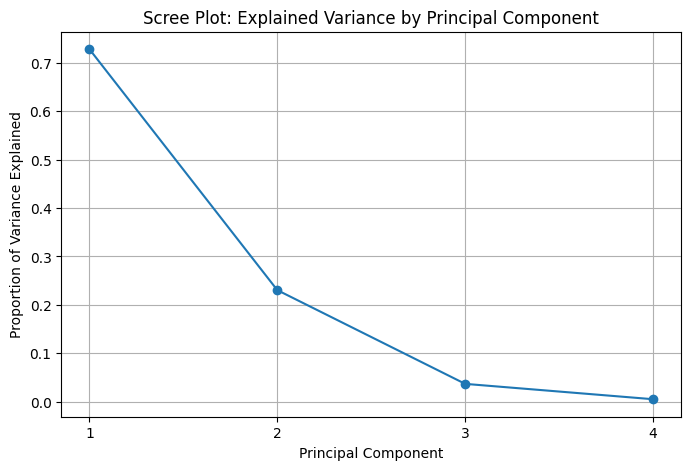

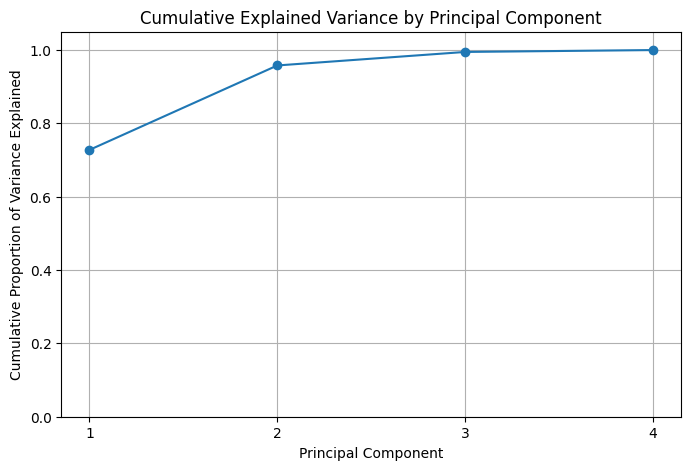

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o', linestyle='-')
plt.title('Scree Plot: Explained Variance by Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.grid(True)
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Proportion of Variance Explained')
plt.grid(True)
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.ylim(0, 1.05)
plt.show()

```markdown
**Pregunta 8**

¿En qué componente parece estabilizarse la variabilidad explicada?

---

# Paso 8. Biplot
```

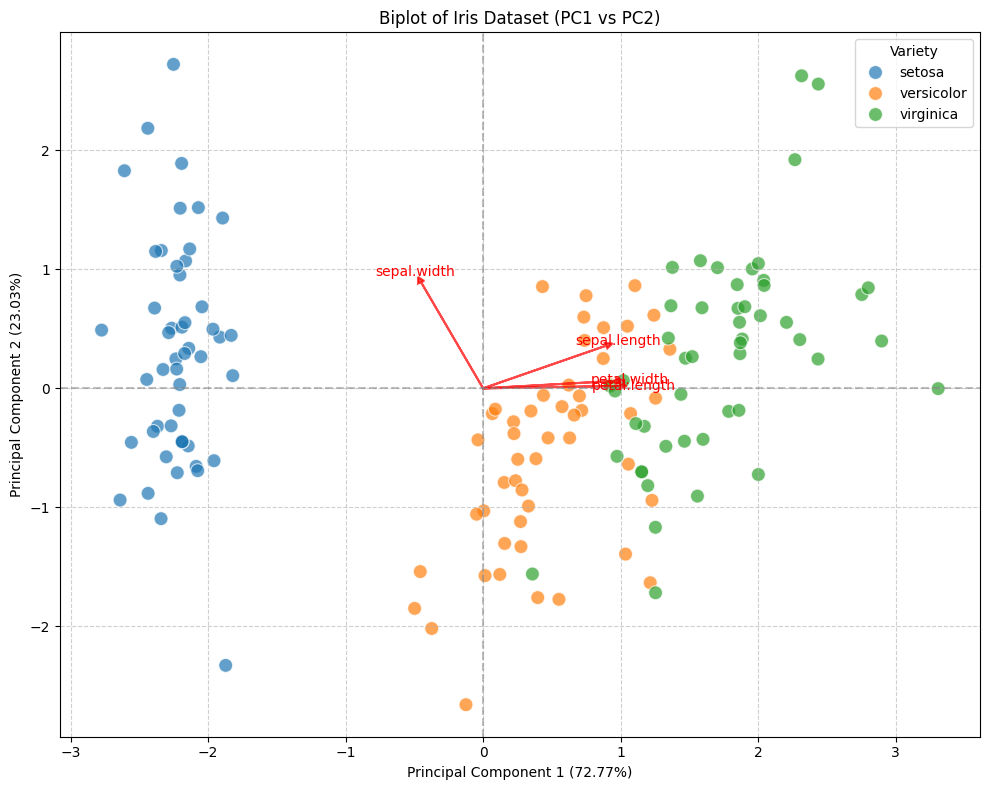

In [9]:
# Create a DataFrame for scores with the 'variety' column
pca_df = pd.DataFrame(data=pca_scores[:, 0:2], columns=['PC1', 'PC2'])
pca_df['variety'] = df['variety']

# Get loadings for PC1 and PC2
loadings = pca.components_[:2, :].T * np.sqrt(pca.explained_variance_[:2])
feature_names = df_num.columns

plt.figure(figsize=(10, 8))

# Scatter plot of observations
sns.scatterplot(x='PC1', y='PC2', hue='variety', data=pca_df, s=100, alpha=0.7)

# Plotting loadings as arrows
for i, (x, y) in enumerate(loadings):
    plt.arrow(0, 0, x, y, color='r', alpha=0.7, linewidth=1.5, head_width=0.05, head_length=0.05)
    plt.text(x * 1.1, y * 1.1, feature_names[i], color='r', ha='center', va='center')

plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('Biplot of Iris Dataset (PC1 vs PC2)')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Variety', loc='upper right')
plt.tight_layout()
plt.show()

```markdown
**Pregunta 9**

¿Se observa separación entre las especies?

---

**Pregunta 10**

¿Qué variables parecen ser responsables de dicha separación?

---

# Conclusiones

Redacte una breve conclusión sobre el ACP realizado.

______________________________________________________________________

______________________________________________________________________

______________________________________________________________________

______________________________________________________________________
```